# XRL-Contrastive: Explaining Multi-Objective RL Agents

**Goal.** Train three multi-objective DQN agents with different reward-channel
priorities ("personalities"), then explain *how* and *why* they behave
differently using three explainability methods: per-channel reward
decomposition, contrastive explanations, and TCAV concept attribution.

**What this notebook is.** A *report*: it loads the trained checkpoints in
`checkpoints/` (no retraining) and renders the analysis. Plotting helpers live
in `report_utils.py` to keep the notebook lean.

**Headline results.**
- All three agents reach the goal with **100% success** (18-step optimal path,
  zero hazard violations) — achieved only after diagnosing and fixing an
  overestimation-driven training collapse.
- On their actual optimal paths the three agents are behaviourally *similar*
  (all reach the goal in 18 steps) and differ mainly in route; the contrastive
  method compares them only at reachable, in-distribution states. Personality
  lives in the reward weights and in counterfactual reactions, not the path.
- TCAV is treated honestly: total-Q TCAV mixes channels and is hard to read; a
  per-channel variant is more principled but its signs are only trustworthy
  where the concept is linearly separable (we report CAV accuracy per cell).


In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
import report_utils as ru
from agents.configs import PROFILES, REWARD_CHANNELS
from envs.multi_obj_grid import MultiObjGridEnv

agents = ru.load_agents()
print("Loaded agents:", ", ".join(agents))

Loaded agents: safety_first, speed_first, balanced


## 1. Problem setup

A 10×10 grid (start `(0,0)`, goal `(9,9)`) with 10 hazard cells (terminal,
reward −10) and 8 resource cells (reward +0.5). Every step costs −0.15. The
environment exposes a **4-channel reward vector** `[goal, safety, coin, step]`
instead of a scalar.

Each agent is a **DecomposedDQN**: a shared encoder feeding four per-channel
Q-heads; the greedy action maximises the weighted sum `Σ wᵢ·Qᵢ`. The weights
define the personality (the reward *signs* live in the reward vector, so all
weights are positive magnitudes):


,agent,"weights [goal,safety,coin,step]",n_step,style
0,Agent α (safety-first),"[1.0, 3.0, 0.3, 0.5]",5,"Avoids hazards aggressively, sacrifices speed ..."
1,Agent β (speed-first),"[2.0, 0.8, 0.3, 2.0]",1,"Reaches goal fast, tolerates risk, ignores coins"
2,Agent γ (balanced),"[1.0, 1.5, 1.0, 0.8]",3,Moderate risk aversion with coin collection


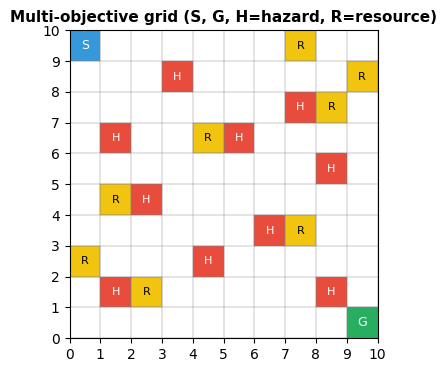

In [2]:
rows = [{"agent": p["name"], "weights [goal,safety,coin,step]": p["weights"],
         "n_step": p["n_step"], "style": p["description"]}
        for p in PROFILES.values()]
display(pd.DataFrame(rows))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4, 4))
ru.draw_grid(MultiObjGridEnv(), title="Multi-objective grid (S, G, H=hazard, R=resource)", ax=ax)
plt.show()

## 2. Training stability — the core engineering problem

Naive training left **all three agents at 0% success**. This was not a
hyperparameter mishap: it is the **overestimation bias / deadly triad** of
value-based deep RL (max operator + bootstrapping + function approximation),
exactly the phenomenon studied in the supervisor's line of work on multi-step
and ensemble DQN. Diagnostic instrumentation showed Q-values diverging (e.g.
`Q_safety` inflating to +600 when it can only ever be ≤ 0) and the greedy policy
collapsing into wall-bumping / self-loops once exploration decayed.

**Antidotes tried, and why the textbook ones failed here:**

| Fix | Outcome | Reason |
|-----|---------|--------|
| Target network (already present) | necessary, insufficient | basic stability only |
| Huber loss | **hurt** | sparse-reward env: the rare ±10 signal *is* the signal; Huber clips exactly it |
| Double DQN | **hurt** | its removal of optimistic bias suppresses the exploration that finds the goal |
| Per-agent **n-step return** | **fixed it** | accumulates real reward before bootstrapping → dilutes the deadly triad |

**Key finding:** the right `n` is *agent-dependent* and interacts with the
reward weights — `β` (high `w_step`) needs `n=1` (large `n` over-amplifies the
step signal into a premature "end the episode" policy); `α` (high `w_safety`)
needs `n=5`; `γ` needs `n=3`. This empirical coupling between fixed-`n` and the
reward structure is precisely what motivates **Elastic Step DQN** (adaptive `n`).

A **best-model checkpoint** (kept the snapshot with the highest training
goal-rate) guards against the late-training divergence that still occurs after
the policy is learned. The dashed lines below mark the saved snapshots.


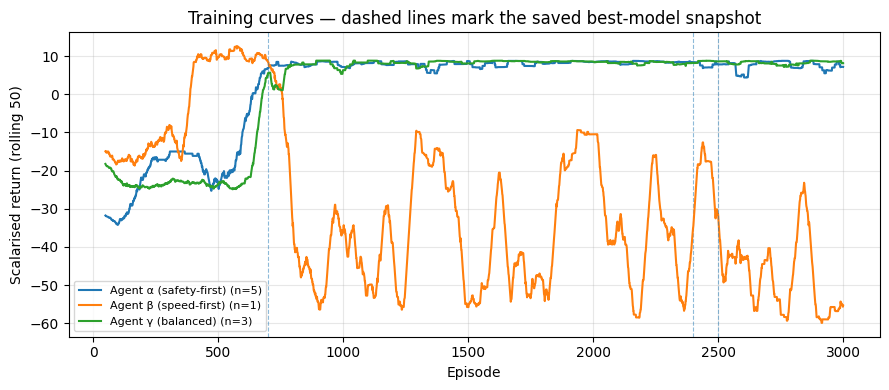

In [3]:
fig = ru.plot_training_curves(agents); import matplotlib.pyplot as plt; plt.show()

## 3. Results — all three agents solve the task

With per-agent n-step + best-model checkpointing, every agent reaches the goal
deterministically (ε=0) on the optimal 18-step path with zero hazard violations.
The personalities still differ in resource collection (R2).


,agent,n_step,success,R1,R2,length,safety_violations
0,Agent α (safety-first),5,1.0,7.3,0.5,18.0,0
1,Agent β (speed-first),1,1.0,7.3,1.0,18.0,0
2,Agent γ (balanced),3,1.0,7.3,1.0,18.0,0


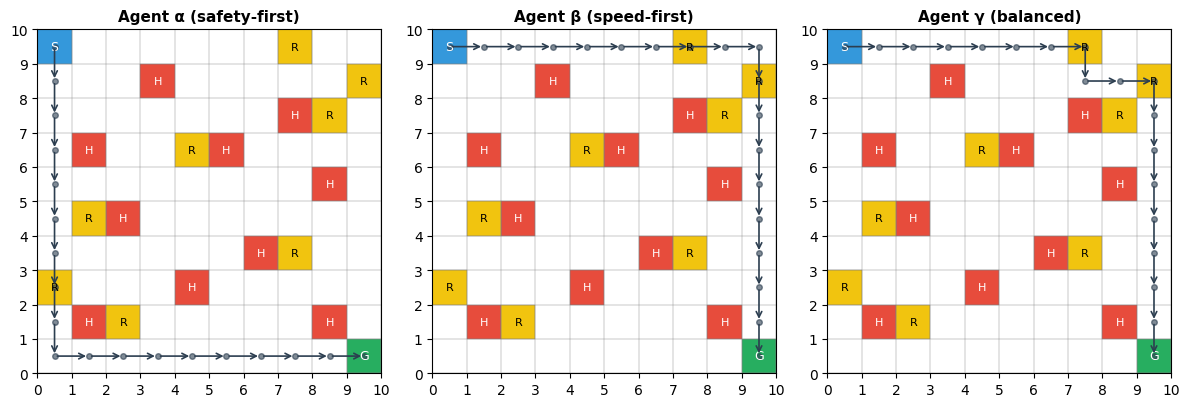

In [4]:
display(pd.DataFrame(ru.metrics_table(agents, n_eval=100)))
fig = ru.plot_trajectories(agents); import matplotlib.pyplot as plt; plt.show()

## 4. Explainability

### 4.1 Reward decomposition

Because the DQN has per-channel heads, every decision decomposes intrinsically:
the contribution of channel `c` to the chosen action is `wᵢ·Qᵢ`. The bars below
show this at the start state.

**What this does and does not show.** The decomposition reliably reveals the
*mechanism*: each action's value is a weighted sum of channel contributions. It
does **not**, on its own, reveal personality — at the (safe) start cell **all
three agents are goal-led**, because with no hazard nearby the safety channel is
≈0 for everyone, so the bars look alike. (This is the honest counterpart to a
tempting but invalid reading of these bars as "agent X cares about channel Y".)

Two facts make this unavoidable: (1) the reward signals are identical across
agents, so the per-channel Q-values are shared *in principle* — only the
**weights** differ; (2) the safety channel only grows large *adjacent to a
hazard*, and those cells lie off the agents' hazard-avoiding optimal paths, where
the learned Q-values are off-distribution and unreliable (we verified e.g. a
`Q_safety` of +6.7, an impossible positive value, at one such cell). So the
personality lives in the **weights** and the **routes** they produce — not in a
single state's decomposition. See Limitations.


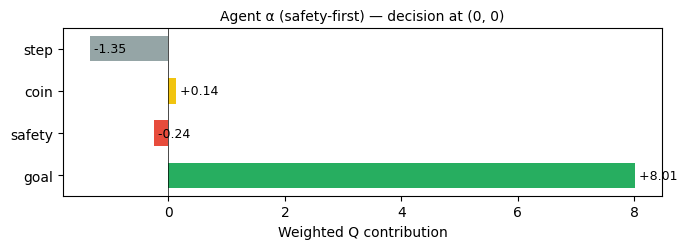

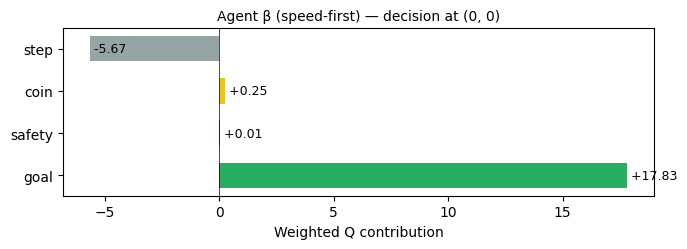

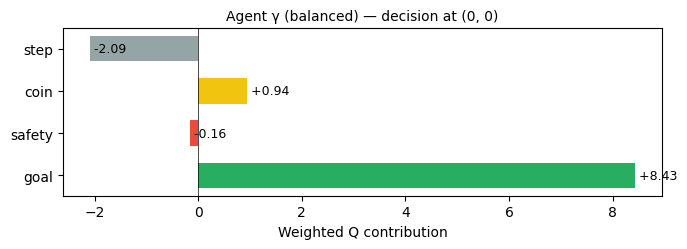

In [5]:
from xai.reward_decomp import trajectory_decomposition
import matplotlib.pyplot as plt
for key, ag in agents.items():
    d = trajectory_decomposition(ag["model"], ag["weights"])[0]
    ru.plot_reward_decomposition(d, title=f"{ag['name']} — decision at {d['position']}")
    plt.show()

### 4.2 Contrastive explanations

We compare agents at states **on their actual greedy trajectories** (the union of
both paths), so every comparison is at a reachable, in-distribution state — not a
random, possibly-unreachable cell where the Q-values would be unreliable. At a
state on agent A's path, agent B's action is a counterfactual ("what would B do
here?"), and vice versa.

**Honest finding:** on their real paths all three agents are *goal-driven* and
differ mainly in **route** — α threads a different corridor, while β and γ are
nearly identical (only a couple of disagreements). The "safety-first vs
speed-first" personality lives in the reward weights and in counterfactual
reactions to hazards the agents never actually approach on an optimal path — not
in the deployed trajectory. This is itself a finding: three competent
multi-objective agents with different weights converge to behaviourally similar
optimal policies; the personality shows up more in representation (TCAV) and
counterfactuals than in the path taken.

All three pairwise comparisons (first two on-path disagreements each):

*For interactive per-state exploration of all three agents at once, run the
dashboard:* `streamlit run dashboard/app.py`.


In [6]:
from xai.contrastive import find_trajectory_disagreements, generate_explanation
import itertools
for ka, kb in itertools.combinations(list(agents), 2):
    a, b = agents[ka], agents[kb]
    dis = find_trajectory_disagreements(a["model"], a["weights"], b["model"], b["weights"])
    print(f"=== {a['name']} vs {b['name']}: {len(dis)} on-path disagreements ===")
    for d in dis[:2]:
        print(generate_explanation(d, a["name"], b["name"])); print()
    print()

=== Agent α (safety-first) vs Agent β (speed-first): 33 on-path disagreements ===
At position (0,0):
  Agent α (safety-first) chose DOWN [→ (1,0): open] (Q_total = +6.55), driven mainly by goal (82%) — heading down brings it closer to the goal.
  Agent β (speed-first) chose RIGHT [→ (0,1): open] (Q_total = +12.43), driven mainly by goal (75%) — heading right brings it closer to the goal.
  → Both prioritise goal here but take different routes — Agent α (safety-first) goes down, Agent β (speed-first) goes right.

At position (1,0):
  Agent α (safety-first) chose DOWN [→ (2,0): open] (Q_total = +6.63), driven mainly by goal (82%) — heading down brings it closer to the goal.
  Agent β (speed-first) chose RIGHT [→ (1,1): open] (Q_total = +11.83), driven mainly by goal (73%) — heading right brings it closer to the goal.
  → Both prioritise goal here but take different routes — Agent α (safety-first) goes down, Agent β (speed-first) goes right.


=== Agent α (safety-first) vs Agent γ (balanc

### 4.3 TCAV concept attribution — baseline vs per-channel

**Baseline (total-Q TCAV).** Standard TCAV on the *total* weighted Q. Because
the four channels are mixed before the gradient, the scores are hard to map to
personality (e.g. the speed-first agent shows low `near_goal` sensitivity).


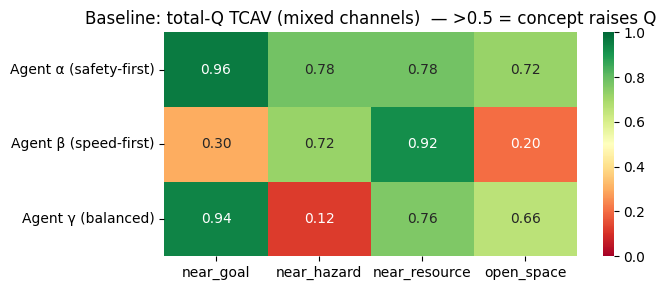

In [7]:
from xai.tcav import run_tcav_analysis
import matplotlib.pyplot as plt
total_tcav = {k: run_tcav_analysis(a["model"], a["weights"], n_samples=120) for k, a in agents.items()}
fig = ru.plot_total_tcav(total_tcav, agents); plt.show()

**Per-channel signed sensitivity (decomposed-Q TCAV).** We probe each head
separately: `mean_s sign(∂(maxₐ Qchannel)/∂features · CAV)` ∈ [−1, 1] for the
semantically matched pairs (safety×hazard, goal×goal, coin×resource).

*Honest caveats, both discovered during implementation:*
1. A cosine-magnitude version washed out to ~0 — in 64-dim feature space the
   gradient and CAV are nearly orthogonal, so only the *sign* is stable.
2. Signs are only trustworthy where the **CAV separates the concept**
   (accuracy shown in each cell). `near_goal` separates well (~0.95); `near_hazard`
   barely (~0.6), so its column should **not** be over-interpreted.

Reading only the reliable `goal×goal` column, the one robust contrastive finding
is that **β (speed-first)'s goal head negatively couples to goal-proximity**
while α/γ are positive — a genuinely surprising result worth flagging rather
than smoothing over.


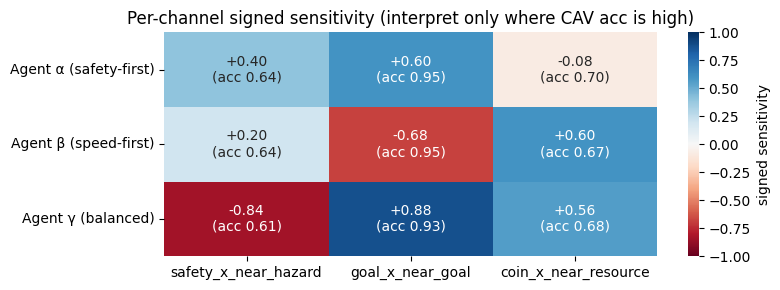

In [8]:
from xai.tcav import run_per_channel_tcav
import matplotlib.pyplot as plt
per_channel = {k: run_per_channel_tcav(a["model"]) for k, a in agents.items()}
fig = ru.plot_per_channel_tcav(per_channel, agents); plt.show()

## 5. Limitations & connection to the research direction

- **Per-channel TCAV reliability is concept-dependent.** Conclusions hold only
  where CAV accuracy is high; `near_hazard` is barely separable in this small
  encoder, so its signs are reported but not interpreted.
- **Reward decomposition does not, by itself, separate the agents.** The reward
  signals are identical across agents, so the per-channel Q-values are shared in
  principle — only the weights differ. On safe cells (the whole optimal path) the
  safety channel is ≈0 and every agent is goal-led; near hazards (off-path) the
  safety channel is large but off-distribution and unreliable. The personality is
  in the weights and the resulting routes, not in any single state's bars.
- **n-step is confounded with the weight profile.** Each agent uses a different
  `n`, so representation-level differences (TCAV) cannot be attributed to
  personality alone. Behaviourally, however, the comparison is clean (all reach
  the same optimal policy). A controlled study (same weights, varying `n`) would
  disentangle this.
- **The training-stability arc is the main contribution.** Independently
  rediscovering overestimation-driven collapse, ruling out Huber/Double-DQN for
  sparse rewards, and finding that the optimal `n` is agent-dependent connects
  directly to **Elastic / Ensemble Step DQN** (adaptive bootstrap horizon).

*Reproduce training (optional):* `python -m experiments.run_all --phase train`.
This report only consumes the committed checkpoints.
